# Pipeline d'entraînement MLlib — Scoring produits d'épargne (V1.1)

Consomme la sortie de `EDA_final.ipynb` (`PATH_TRAIN_OUT` / `PATH_SCORER_OUT` — parquet nettoyé,
catégorielles encore brutes). Encode, assemble, entraîne, évalue, sauvegarde, puis score.

**Principe de non-fuite** : tout ce qui est appris (indexeurs, encodeurs, poids de classe, modèle)
est **fit uniquement sur le train**, sauvegardé en `PipelineModel`, puis **rechargé tel quel** pour
scorer `dataset_a_scorer` — même logique que l'`Imputer`/les bornes IQR/les flags dans la Partie 1
EDA.

**Corrections apportées dans cette version (vs. V1) :**
- Ajout du **nettoyage de frontière par Tomek Links** (guide section 7.6bis), en pandas, sur le
  train étiqueté uniquement, **avant** le split train/validation.
- Ajout de la **pondération inverse-fréquence par classe** (guide section 7.6), recalculée
  **après** Tomek Links (la distribution des classes change), injectée via `weightCol` dans le
  classifieur.
- Correction d'une affirmation fausse en section 10 (V1) : `RandomForestClassifier` **supporte**
  `weightCol` depuis Spark 3.0 — le guide (section 7.5) l'utilise explicitement. La V1 prétendait
  le contraire, ce qui n'était pas cohérent avec le guide.
- Le lookup manuel `F.udf(...)` en section scoring remplacé par `IndexToString` (guide section
  7.3), qui est l'outil MLlib documenté pour cette conversion indice → nom de produit.

**Plan :**
1. Imports & configuration
2. Chargement du train nettoyé
3. Nettoyage de frontière (Tomek Links)
4. Split train / validation
5. Pondération inverse-fréquence par classe
6. Construction du pipeline (encodage → assemblage → modèle pondéré)
7. Entraînement
8. Évaluation (accuracy, F1 pondéré, matrice de confusion)
9. Importance des variables
10. Refit sur 100% du train (poids recalculés) & sauvegarde
11. Scoring (`dataset_a_scorer`)
12. Limites de cette V1.1 & prochaines étapes

## 1. Imports & configuration

In [1]:
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, IndexToString
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# pip install imbalanced-learn --break-system-packages (si pas déjà présent dans l'environnement)
from imblearn.under_sampling import TomekLinks


In [2]:
# ═══ Bascule LOCAL / MinIO — même principe que la Partie 1 EDA ═══
LOCAL_MODE = True

if LOCAL_MODE:
    # Pour l'instant : le CSV nettoyé exporté par EDA_final.ipynb (Partie 1 -> Partie 2).
    # Une fois le pipeline validé en local, on rebasculera sur le parquet produit par
    # traiter_dataset(is_train=True) puis, à terme, sur le bucket MinIO (branche else ci-dessous).
    PATH_TRAIN_IN = "final_eligibilite.csv"
    PATH_SCORER_IN = None                                    # pas encore testé en local
    PATH_PREDICTIONS_OUT = "new_test/predictions.parquet"
    MODEL_PATH = "./models/scoring_pipeline"
else:
    PATH_TRAIN_IN = "s3a://processed-data/dataset_train_produits_final/"
    PATH_SCORER_IN = "s3a://processed-data/dataset_a_scorer_final/"
    PATH_PREDICTIONS_OUT = "s3a://processed-data/predictions/"
    MODEL_PATH = "s3a://ml-scoring/models/scoring_pipeline"

RANDOM_SEED = 42


In [3]:
# CORRECTIF POTENTIEL : ces deux listes DOIVENT rester identiques à celles de la
# Partie 1 EDA (section 0) -- si l'une évolue sans l'autre, le pipeline plante au
# fit (colonne absente) ou encode silencieusement moins de colonnes que prévu.
# TODO V2 : factoriser dans un module partagé (ex. config.py) importé par les deux
# notebooks, plutôt que dupliqué ici.
COLS_CATEGORIELLES_BASSE_CARDINALITE = [
    "GENDER", "TAILLE_ENTREPRI", "pack_actuel", "pack_etat",
    "CUSTOMER_RATING", "MARITAL_STATUS", "BPR",
]
# CORRECTIF : BPR est un code numérique (int64, 12 modalités : 1, 17, 27, 30,
# 43, 45, 50, 57, 64, 78, 81, 90) sans relation d'ordre -- ce n'est PAS une
# quantité. Laissé tel quel, il finissait dans colonnes_features_numeriques()
# (section 6/7) comme feature numérique brute : le modèle apprenait un ordre
# arbitraire entre les codes (78 > 45) qui n'a aucun sens métier. Basse
# cardinalité (12) -> sa place est ici, StringIndexer + OneHotEncoder
# (section 6) plutôt qu'assemblé tel quel comme numérique. Même logique à
# appliquer à toute future colonne "code" numérique à faible cardinalité --
# ne pas se fier au dtype pandas/Spark, se fier au nombre de modalités.
COL_HAUTE_CARDINALITE = "CODE_VILLE"  # indexé seul, jamais one-hot (haute cardinalité -- nb exact calculé dynamiquement section 6, cf. nb_modalites_ville)
COL_LABEL = "label_eligibilite"
COLS_A_EXCLURE_DES_FEATURES = ["label_code", "label_eligibilite"]  # cible, sous ses deux formes


## 2. Spark session & chargement du train nettoyé

In [4]:
def get_spark() -> SparkSession:
    builder = SparkSession.builder.appName("training_pipeline_scoring")
    if LOCAL_MODE:
        # CORRECTIF (OOM) : jamais configuré -> spark.driver.memory par défaut (1g).
        # En local[*], driver et executors partagent la même JVM -- avec maxBins ~863
        # (CODE_VILLE, section 6), TOUTES les features de l'arbre sont binnées sur ce
        # même nombre de bins, pas seulement CODE_VILLE_idx -- les statistiques par
        # noeud explosent, surtout avec CrossValidator (section 9bis) qui fait tourner
        # plusieurs fits en parallèle. 6g est un point de départ raisonnable pour un
        # poste de dev -- ajuster à la baisse/hausse selon la RAM disponible (ne pas
        # dépasser ~70-80% de la RAM physique).
        builder = builder.master("local[*]").config("spark.driver.memory", "6g")
    else:
        builder = (
            builder.master("spark://spark-master:7077")
            .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000")
            .config("spark.hadoop.fs.s3a.access.key", "minioadmin")
            .config("spark.hadoop.fs.s3a.secret.key", "minioadmin123")
            .config("spark.hadoop.fs.s3a.path.style.access", "true")
            .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
        )
    spark = builder.getOrCreate()
    spark.sparkContext.setLogLevel("WARN")
    return spark


def charger_dataset(path: str) -> DataFrame:
    """Charge le dataset nettoyé (sortie de la Partie 1 EDA), en CSV (mode local
    actuel, ex. final.csv) ou en parquet (bucket MinIO, une fois LOCAL_MODE=False).

    Le CSV n'a pas de schéma typé natif -- inferSchema le lirait sans distinction
    entre catégorielle et numérique. Danger particulier : CODE_VILLE (haute
    cardinalité, section 6/COL_HAUTE_CARDINALITE) contient des valeurs comme
    "101", "780" -- inferSchema les lirait comme entier, ce qui casserait le
    StringIndexer prévu pour cette colonne (traitée comme catégorielle, jamais
    comme une quantité). On la recast explicitement en string après lecture.
    """
    if path.endswith(".csv"):
        df = spark.read.csv(path, header=True, inferSchema=True)
        df = df.withColumn(COL_HAUTE_CARDINALITE, F.col(COL_HAUTE_CARDINALITE).cast("string"))
        return df
    return spark.read.parquet(path)


spark = get_spark()
df_train_full = charger_dataset(PATH_TRAIN_IN)
print(f"{df_train_full.count()} lignes, {len(df_train_full.columns)} colonnes")
df_train_full.printSchema()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/15 11:49:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/15 11:49:14 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/07/15 11:49:14 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


95326 lignes, 40 colonnes
root
 |-- CODE_VILLE: string (nullable = true)
 |-- BPR: integer (nullable = true)
 |-- GENDER: string (nullable = true)
 |-- MARITAL_STATUS: string (nullable = true)
 |-- NOMBRE_ENFANT: integer (nullable = true)
 |-- CUSTOMER_RATING: string (nullable = true)
 |-- TAILLE_ENTREPRI: string (nullable = true)
 |-- age_client: integer (nullable = true)
 |-- pack_actuel: string (nullable = true)
 |-- pack_etat: string (nullable = true)
 |-- solde_moyen: double (nullable = true)
 |-- solde_min: double (nullable = true)
 |-- nb_mois_observes_solde: integer (nullable = true)
 |-- depot_moyen: double (nullable = true)
 |-- flux_cred_total: double (nullable = true)
 |-- nb_mois_avec_flux: integer (nullable = true)
 |-- nb_operations_gab: integer (nullable = true)
 |-- montant_total_gab: double (nullable = true)
 |-- montant_moyen_gab: double (nullable = true)
 |-- nb_retraits: integer (nullable = true)
 |-- montant_total_retraits: double (nullable = true)
 |-- nb_paiemen

In [5]:
def colonnes_features_numeriques(df: DataFrame) -> list:
    """Toutes les colonnes numériques du dataset, hors cible et hors colonnes
    catégorielles couvertes par l'encodage (section 6) -- sinon on se retrouverait
    avec CODE_VILLE brut ET CODE_VILLE_idx dans le vecteur final. Utilisée à la
    fois pour Tomek Links (section 3, sur les features numériques uniquement --
    TomekLinks calcule des distances, incompatible avec des catégorielles brutes
    non encodées à ce stade) et pour VectorAssembler (section 6)."""
    cols_categorielles_brutes = set(COLS_CATEGORIELLES_BASSE_CARDINALITE + [COL_HAUTE_CARDINALITE])
    return [
        c for c, t in df.dtypes
        if t in ("int", "bigint", "double", "float")
        and c not in COLS_A_EXCLURE_DES_FEATURES
        and c not in cols_categorielles_brutes
    ]


feature_cols_numeriques = colonnes_features_numeriques(df_train_full)
print(f"Features numériques ({len(feature_cols_numeriques)}) : {feature_cols_numeriques}")


Features numériques (31) : ['NOMBRE_ENFANT', 'age_client', 'solde_moyen', 'solde_min', 'nb_mois_observes_solde', 'depot_moyen', 'flux_cred_total', 'nb_mois_avec_flux', 'nb_operations_gab', 'montant_total_gab', 'montant_moyen_gab', 'nb_retraits', 'montant_total_retraits', 'nb_paiements_digitaux', 'montant_total_payfac', 'nb_vignettes_payees', 'montant_total_vignette', 'jamais_active_digital', 'jamais_utilise_gab', 'anciennete_digitale_jours_imp', 'recence_gab_jours_imp', 'nb_mois_observes_solde_etait_extreme', 'solde_moyen_etait_extreme', 'solde_min_etait_extreme', 'solde_max_etait_extreme', 'depot_moyen_etait_extreme', 'flux_cred_moyen_etait_extreme', 'flux_cred_total_etait_extreme', 'montant_total_retraits_etait_extreme', 'solde_volatilite_indefinie', 'solde_volatilite_relative_imp']


## 3. Nettoyage de frontière (Tomek Links)

Guide, section 7.6bis. Un lien de Tomek est une paire de points de classes différentes qui sont
chacun le plus proche voisin de l'autre — un signal de frontière, voire d'empiètement de la
classe majoritaire sur la zone d'une classe minoritaire. Les supprimer nettoie la frontière de
décision. **Complémentaire à la pondération de classe (section 5), pas un substitut** : Tomek
Links agit sur les *lignes* avant l'entraînement, la pondération agit sur la *fonction de coût*
pendant l'entraînement.

**Pourquoi en pandas et pas en Spark** : `imbalanced-learn` n'a pas d'équivalent distribué
natif dans MLlib. Ce n'est pas un problème ici : Tomek Links ne s'applique **qu'au train
étiqueté** (ce fichier), jamais à `dataset_a_scorer` (potentiellement 3M+ lignes une fois sur
MinIO) — un aller-retour pandas sur un fichier de cette taille est sans risque mémoire.

**Ordre à respecter** (guide) : Tomek Links tourne **avant** le split train/validation (section 4)
et **avant** le calcul des poids de classe (section 5, qui doit refléter la distribution
post-Tomek, pas la distribution brute).

In [6]:
RADICAL_PRESENT = "RADICAL" in df_train_full.columns

# CORRECTIF : on sélectionne désormais TOUTES les colonnes de df_train_full (pas
# seulement RADICAL + numériques + label). L'ancienne version, quand RADICAL était
# absent (cas de final.csv, colonnes techniques déjà supprimées en amont), retombait
# sur train_pd_clean qui ne contenait QUE les numériques + le label -- les
# catégorielles brutes (GENDER, MARITAL_STATUS, ...) disparaissaient de
# df_train_full et l'encodage (section 6) plantait plus loin avec "Input column
# GENDER does not exist". En gardant toutes les colonnes ici, indices_conserves
# (calculé sur les seules features numériques, cf. plus bas) reste valide pour
# indexer train_pd puisque son index pandas n'a pas changé -- et le rejoin
# RADICAL devient inutile, qu'il soit présent ou non.
cols_tomek = df_train_full.columns

train_pd = df_train_full.select(*cols_tomek).toPandas()
print(f"Avant Tomek Links : {len(train_pd)} lignes")
print(train_pd[COL_LABEL].value_counts())

X = train_pd[feature_cols_numeriques]
y = train_pd[COL_LABEL]

tomek = TomekLinks(sampling_strategy="auto")
X_res, y_res = tomek.fit_resample(X, y)

# fit_resample renvoie de nouveaux index -- on les utilise pour retrouver les
# lignes conservées, avec TOUTES les colonnes d'origine (cf. correctif ci-dessus),
# pas seulement les features numériques utilisées pour le calcul des distances.
indices_conserves = X_res.index
train_pd_clean = train_pd.loc[indices_conserves].reset_index(drop=True)

print(f"Après Tomek Links : {len(train_pd_clean)} lignes "
      f"({len(train_pd) - len(train_pd_clean)} supprimée(s), frontière entre classes)")
print(train_pd_clean[COL_LABEL].value_counts())

# Retour dans Spark : train_pd_clean porte déjà toutes les colonnes, plus besoin
# de rejoindre sur RADICAL pour les récupérer.
df_train_full = spark.createDataFrame(train_pd_clean)

df_train_full.cache()
print(f"\ndf_train_full après Tomek Links : {df_train_full.count()} lignes")


26/07/15 11:49:29 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Avant Tomek Links : 95326 lignes
label_eligibilite
0    91321
1     4005
Name: count, dtype: int64
Après Tomek Links : 93460 lignes (1866 supprimée(s), frontière entre classes)
label_eligibilite
0    89553
1     3907
Name: count, dtype: int64


26/07/15 11:50:12 WARN TaskSetManager: Stage 6 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:15 WARN TaskSetManager: Stage 7 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.



df_train_full après Tomek Links : 93460 lignes


## 4. Split train / validation

Un split est fait ici **en plus** du train/scoring déjà séparé en amont (Partie 1 EDA) : celui-là
sépare "données qu'on a le droit d'utiliser" de "données de production", celui-ci sépare "données
pour entraîner" de "données pour évaluer honnêtement avant de livrer le modèle". Sans ce split, la
métrique d'évaluation serait mesurée sur les données mêmes qui ont servi à fitter les indexeurs et
le classifieur -- optimiste, pas fiable.

Split fait **après** Tomek Links (section 3), sur `df_train_full` déjà nettoyé -- le `PipelineModel`
final (section 10) sera de toute façon refit sur 100% de ce `df_train_full` nettoyé une fois la
V1.1 validée ici.

In [7]:
df_fit, df_val = df_train_full.randomSplit([0.8, 0.2], seed=RANDOM_SEED)
df_fit.cache()
df_val.cache()
print(f"Fit  : {df_fit.count()} lignes")
print(f"Val  : {df_val.count()} lignes")

print("\nÉquilibre des classes -- fit vs val (doivent être comparables) :")
df_fit.groupBy(COL_LABEL).count().withColumn("part_fit", F.round(F.col("count") / df_fit.count(), 3)).show()
df_val.groupBy(COL_LABEL).count().withColumn("part_val", F.round(F.col("count") / df_val.count(), 3)).show()


26/07/15 11:50:16 WARN TaskSetManager: Stage 10 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:18 WARN TaskSetManager: Stage 11 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


Fit  : 74995 lignes


26/07/15 11:50:18 WARN TaskSetManager: Stage 14 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:19 WARN TaskSetManager: Stage 15 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:19 WARN TaskSetManager: Stage 18 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


Val  : 18465 lignes

Équilibre des classes -- fit vs val (doivent être comparables) :


26/07/15 11:50:20 WARN TaskSetManager: Stage 21 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


+-----------------+-----+--------+
|label_eligibilite|count|part_fit|
+-----------------+-----+--------+
|                0|71844|   0.958|
|                1| 3151|   0.042|
+-----------------+-----+--------+



26/07/15 11:50:21 WARN TaskSetManager: Stage 24 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:21 WARN TaskSetManager: Stage 27 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


+-----------------+-----+--------+
|label_eligibilite|count|part_val|
+-----------------+-----+--------+
|                0|17709|   0.959|
|                1|  756|   0.041|
+-----------------+-----+--------+



## 5. Pondération inverse-fréquence par classe

Guide, section 7.6. Complémentaire à Tomek Links (section 3) : Tomek nettoie les lignes
ambiguës à la frontière, la pondération force le classifieur à ne pas ignorer les classes rares
pendant l'apprentissage. **Calculée après Tomek Links**, sur `df_fit` -- la distribution des
classes a changé suite au nettoyage de frontière, un poids calculé sur la distribution brute
d'avant-Tomek serait faux.

Formule (guide) : `poids_classe = total / (nb_classes × effectif_de_la_classe)` -- pondération
inverse-fréquence standard multi-classe, chaque classe rare reçoit un poids proportionnellement
plus élevé.

In [8]:
def calculer_poids_classe(df: DataFrame, col_label: str = COL_LABEL) -> DataFrame:
    """Retourne un DataFrame [col_label, poids_classe] à joindre sur le train
    (fit ou full) juste avant l'entraînement. Recalculé à chaque fois que la
    population d'entrée change (ex. fit vs. full au refit de la section 10)."""
    effectifs = df.groupBy(col_label).count()
    total = df.count()
    nb_classes = effectifs.count()

    poids = effectifs.withColumn(
        "poids_classe", total / (nb_classes * F.col("count"))
    ).select(col_label, "poids_classe")

    print(f"\nPoids par classe (total={total}, nb_classes={nb_classes}) :")
    poids.orderBy(col_label).show()
    return poids


poids_par_classe_fit = calculer_poids_classe(df_fit)
df_fit = df_fit.join(poids_par_classe_fit, on=COL_LABEL)


26/07/15 11:50:22 WARN TaskSetManager: Stage 30 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:22 WARN TaskSetManager: Stage 33 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.



Poids par classe (total=74995, nb_classes=2) :


26/07/15 11:50:23 WARN TaskSetManager: Stage 39 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


+-----------------+------------------+
|label_eligibilite|      poids_classe|
+-----------------+------------------+
|                0|0.5219294582706976|
|                1|11.900190415741035|
+-----------------+------------------+



## 6. Construction du pipeline

Trois familles de stages, dans l'ordre où Spark doit les exécuter :

1. **Encodage catégoriel** : `StringIndexer` + `OneHotEncoder` pour les colonnes basse-cardinalité,
   `StringIndexer` seul pour `CODE_VILLE` (haute cardinalité — un `OneHotEncoder` dessus
   exploserait le nombre de features pour un gain incertain).
2. **Indexation de la cible** : `label_nom` (string) → `label_idx` (double), requis par les
   classifieurs MLlib.
3. **Assemblage** : toutes les features numériques + toutes les sorties d'encodage dans un seul
   vecteur `features`, puis le classifieur, **pondéré par `poids_classe`** (section 5).

`RandomForestClassifier` choisi pour cette V1.1 : robuste aux features non standardisées, gère
nativement `CODE_VILLE_idx` à haute cardinalité sans que l'ordre numérique arbitraire de l'index
ne biaise le modèle (contrairement à une régression logistique), **et supporte `weightCol`
nativement depuis Spark 3.0** — exactement l'exemple du guide (section 7.5).

In [9]:
def construire_stages_encodage(cols_basse_cardinalite: list, col_haute_cardinalite: str):
    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in cols_basse_cardinalite
    ]
    encoders = [
        OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
        for c in cols_basse_cardinalite
    ]
    indexer_haute_card = StringIndexer(
        inputCol=col_haute_cardinalite, outputCol=f"{col_haute_cardinalite}_idx", handleInvalid="keep"
    )
    return indexers + encoders + [indexer_haute_card]


encodage_stages = construire_stages_encodage(COLS_CATEGORIELLES_BASSE_CARDINALITE, COL_HAUTE_CARDINALITE)

label_indexer = StringIndexer(inputCol=COL_LABEL, outputCol="label_idx", handleInvalid="error")

feature_cols_encodees = [f"{c}_ohe" for c in COLS_CATEGORIELLES_BASSE_CARDINALITE] + [f"{COL_HAUTE_CARDINALITE}_idx"]
feature_cols = feature_cols_numeriques + feature_cols_encodees

print(f"Features numériques ({len(feature_cols_numeriques)}) : {feature_cols_numeriques}")
print(f"Features encodées   ({len(feature_cols_encodees)}) : {feature_cols_encodees}")

# handleInvalid="skip" : "poids_classe" n'est PAS dans inputCols, VectorAssembler
# ne le touche pas -- il reste disponible comme colonne à part pour weightCol ci-dessous.
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

# CORRECTIF : RandomForestClassifier traite CODE_VILLE_idx comme une feature
# catégorielle (métadonnée posée par le StringIndexer) et exige maxBins >= son
# nombre de modalités -- sinon Spark lève IllegalArgumentException au .fit().
# maxBins par défaut (32) est très inférieur aux ~273 modalités de CODE_VILLE
# (guide / COL_HAUTE_CARDINALITE) : on le dimensionne dynamiquement plutôt que
# de fixer une valeur en dur qui casserait si la cardinalité évolue.
nb_modalites_ville = df_train_full.select(COL_HAUTE_CARDINALITE).distinct().count()
max_bins = max(32, nb_modalites_ville + 1)  # +1 : marge pour la modalité "inconnue" (handleInvalid="keep")
print(f"CODE_VILLE : {nb_modalites_ville} modalités observées -> maxBins={max_bins}")

# CORRECTIF (bug bloquant) : max_bins est calculé dynamiquement juste au-dessus
# (>= nb de modalités de CODE_VILLE, ici ~863) mais le classifieur utilisait
# "maxBins=64" en dur -- très inférieur à ~863, ce qui fait planter .fit() avec
# IllegalArgumentException, exactement l'erreur que le commentaire au-dessus
# prétend éviter. La section 9bis (benchmark) utilisait déjà correctement
# "maxBins=max_bins" -- on aligne ici sur la même variable.
clf = RandomForestClassifier(
    labelCol="label_idx",
    featuresCol="features",
    weightCol="poids_classe",
    numTrees=30,
    maxDepth=5,
    maxBins=max_bins,
    seed=RANDOM_SEED,
)

pipeline = Pipeline(stages=encodage_stages + [label_indexer, assembler, clf])


Features numériques (31) : ['NOMBRE_ENFANT', 'age_client', 'solde_moyen', 'solde_min', 'nb_mois_observes_solde', 'depot_moyen', 'flux_cred_total', 'nb_mois_avec_flux', 'nb_operations_gab', 'montant_total_gab', 'montant_moyen_gab', 'nb_retraits', 'montant_total_retraits', 'nb_paiements_digitaux', 'montant_total_payfac', 'nb_vignettes_payees', 'montant_total_vignette', 'jamais_active_digital', 'jamais_utilise_gab', 'anciennete_digitale_jours_imp', 'recence_gab_jours_imp', 'nb_mois_observes_solde_etait_extreme', 'solde_moyen_etait_extreme', 'solde_min_etait_extreme', 'solde_max_etait_extreme', 'depot_moyen_etait_extreme', 'flux_cred_moyen_etait_extreme', 'flux_cred_total_etait_extreme', 'montant_total_retraits_etait_extreme', 'solde_volatilite_indefinie', 'solde_volatilite_relative_imp']
Features encodées   (8) : ['GENDER_ohe', 'TAILLE_ENTREPRI_ohe', 'pack_actuel_ohe', 'pack_etat_ohe', 'CUSTOMER_RATING_ohe', 'MARITAL_STATUS_ohe', 'BPR_ohe', 'CODE_VILLE_idx']


26/07/15 11:50:24 WARN TaskSetManager: Stage 42 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


CODE_VILLE : 855 modalités observées -> maxBins=856


## 6bis. Aperçu des données encodées

Avant l'entraînement, on vérifie concrètement ce que produisent les `StringIndexer`/`OneHotEncoder`
de la section 6 sur quelques colonnes catégorielles, et à quoi ressemble le vecteur `features` final
assemblé par le `VectorAssembler`. Utile pour repérer une colonne mal encodée avant de lancer un
`.fit()` qui prend du temps sur le vrai classifieur.

In [10]:
# Pipeline "encodage seul" (mêmes stages que la section 6, sans classifieur) -- permet
# de visualiser brut -> index -> one-hot -> vecteur "features" assemblé, sans attendre
# l'entraînement d'un modèle complet.
pipeline_encodage_apercu = Pipeline(stages=encodage_stages + [label_indexer, assembler])
apercu_model = pipeline_encodage_apercu.fit(df_fit)
df_encode_apercu = apercu_model.transform(df_fit)

# 3 colonnes basse-cardinalité suffisent pour illustrer brut -> idx -> ohe, plus CODE_VILLE
# (haute cardinalité, indexé seul) et le vecteur assemblé final.
cols_a_montrer = []
for c in COLS_CATEGORIELLES_BASSE_CARDINALITE[:3]:
    cols_a_montrer += [c, f"{c}_idx", f"{c}_ohe"]
cols_a_montrer += [COL_HAUTE_CARDINALITE, f"{COL_HAUTE_CARDINALITE}_idx", COL_LABEL, "label_idx", "features"]

print("Exemple de lignes encodées :")
df_encode_apercu.select(*cols_a_montrer).show(5, truncate=60)

# Une seule ligne en pandas, vecteur "features" déplié en array pour le lire en clair
exemple_pd = df_encode_apercu.select(*cols_a_montrer).limit(1).toPandas()
exemple_pd["features"] = exemple_pd["features"].apply(lambda v: v.toArray())
exemple_pd.T.rename(columns={0: "valeur_exemple"})

26/07/15 11:50:25 WARN TaskSetManager: Stage 48 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:26 WARN TaskSetManager: Stage 51 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:27 WARN TaskSetManager: Stage 57 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:27 WARN TaskSetManager: Stage 60 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:28 WARN TaskSetManager: Stage 66 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:28 WARN TaskSetManager: Stage 69 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:29 WARN TaskSetManager: Stage 75 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/

Exemple de lignes encodées :


26/07/15 11:50:34 WARN TaskSetManager: Stage 129 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:35 WARN TaskSetManager: Stage 132 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


+------+----------+-------------+---------------+-------------------+-------------------+-----------+---------------+---------------+----------+--------------+-----------------+---------+------------------------------------------------------------+
|GENDER|GENDER_idx|   GENDER_ohe|TAILLE_ENTREPRI|TAILLE_ENTREPRI_idx|TAILLE_ENTREPRI_ohe|pack_actuel|pack_actuel_idx|pack_actuel_ohe|CODE_VILLE|CODE_VILLE_idx|label_eligibilite|label_idx|                                                    features|
+------+----------+-------------+---------------+-------------------+-------------------+-----------+---------------+---------------+----------+--------------+-----------------+---------+------------------------------------------------------------+
|     M|       0.0|(2,[0],[1.0])|    PARTICULIER|                0.0|      (2,[0],[1.0])|  SANS_PACK|            0.0| (78,[0],[1.0])|         0|         292.0|                0|      0.0|(152,[0,1,2,3,4,5,6,7,17,18,19,20,30,31,33,35,114,117,133...|
|   

26/07/15 11:50:35 WARN TaskSetManager: Stage 133 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:36 WARN TaskSetManager: Stage 136 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


,valeur_exemple
GENDER,M
GENDER_idx,0.0
GENDER_ohe,"(1.0, 0.0)"
TAILLE_ENTREPRI,PARTICULIER
TAILLE_ENTREPRI_idx,0.0
TAILLE_ENTREPRI_ohe,"(1.0, 0.0)"
pack_actuel,SANS_PACK
pack_actuel_idx,0.0
pack_actuel_ohe,"(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
CODE_VILLE,0


## 7. Entraînement

Un seul `.fit()` déclenche, dans l'ordre, le fit de chaque `StringIndexer`/`OneHotEncoder` (appris
sur `df_fit` uniquement) puis l'entraînement du `RandomForestClassifier`, pondéré par
`poids_classe`.

In [11]:
pipeline_model = pipeline.fit(df_fit)
print("Entraînement terminé.")


26/07/15 11:50:36 WARN TaskSetManager: Stage 137 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:36 WARN TaskSetManager: Stage 138 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:37 WARN TaskSetManager: Stage 148 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:37 WARN TaskSetManager: Stage 151 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:38 WARN TaskSetManager: Stage 157 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:38 WARN TaskSetManager: Stage 160 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:50:39 WARN TaskSetManager: Stage 166 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.

Entraînement terminé.


## 8. Évaluation sur le set de validation

Accuracy seule est trompeuse ici (cible déséquilibrée, cf. EDA Partie 2 section 3) — F1 pondéré et
la matrice de confusion donnent une image plus honnête, en particulier sur les classes
minoritaires. `df_val` n'a **pas** de colonne `poids_classe` (jointe uniquement sur `df_fit` en
section 5) — c'est volontaire, l'évaluation doit rester sur la distribution réelle, pas pondérée.

In [12]:
predictions_val = pipeline_model.transform(df_val)

evaluator_acc = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedRecall")

print(f"Accuracy           : {evaluator_acc.evaluate(predictions_val):.4f}")
print(f"F1 pondéré         : {evaluator_f1.evaluate(predictions_val):.4f}")
print(f"Précision pondérée : {evaluator_precision.evaluate(predictions_val):.4f}")
print(f"Rappel pondéré     : {evaluator_recall.evaluate(predictions_val):.4f}")


26/07/15 11:50:58 WARN TaskSetManager: Stage 246 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


Accuracy           : 0.7353


26/07/15 11:50:59 WARN TaskSetManager: Stage 248 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


F1 pondéré         : 0.8149


26/07/15 11:51:00 WARN TaskSetManager: Stage 250 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


Précision pondérée : 0.9397


26/07/15 11:51:01 WARN TaskSetManager: Stage 252 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


Rappel pondéré     : 0.7353


Correspondance label_idx -> label_nom : {0: '0', 1: '1'}


26/07/15 11:51:02 WARN TaskSetManager: Stage 254 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.



Matrice de confusion (lignes = réel, colonnes = prédit) :
label_nom_predit      0     1    All
label_nom_reel                      
0                 13143  4566  17709
1                   322   434    756
All               13465  5000  18465


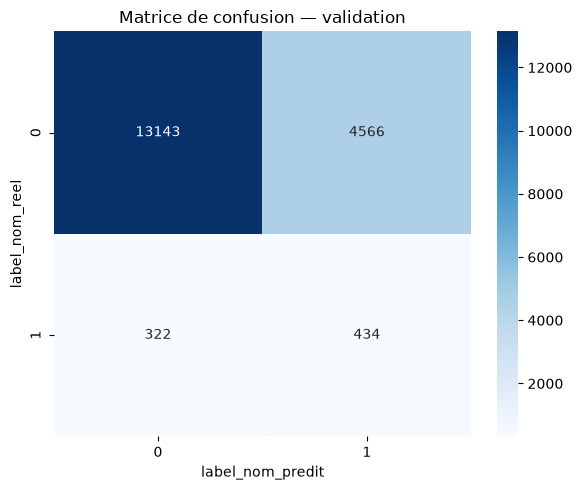

In [13]:
# Matrice de confusion (le set de validation est petit -- OK de collecter en pandas ;
# sur un dataset_a_scorer complet de plusieurs millions de lignes, échantillonner d'abord)
label_map = dict(enumerate(pipeline_model.stages[len(encodage_stages)].labels))  # label_idx -> label_nom
print("Correspondance label_idx -> label_nom :", label_map)

pred_pd = predictions_val.select("label_idx", "prediction").toPandas()
pred_pd["label_nom_reel"] = pred_pd["label_idx"].map(label_map)
pred_pd["label_nom_predit"] = pred_pd["prediction"].map(label_map)

confusion = pd.crosstab(pred_pd["label_nom_reel"], pred_pd["label_nom_predit"], margins=True)
print("\nMatrice de confusion (lignes = réel, colonnes = prédit) :")
print(confusion)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pd.crosstab(pred_pd["label_nom_reel"], pred_pd["label_nom_predit"]), annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Matrice de confusion — validation")
plt.tight_layout()
plt.show()


## 9. Importance des variables

Utile pour vérifier que le modèle s'appuie sur des signaux plausibles (pas uniquement
`CODE_VILLE_idx` ou un artefact du feature engineering) avant de livrer la V1.1.

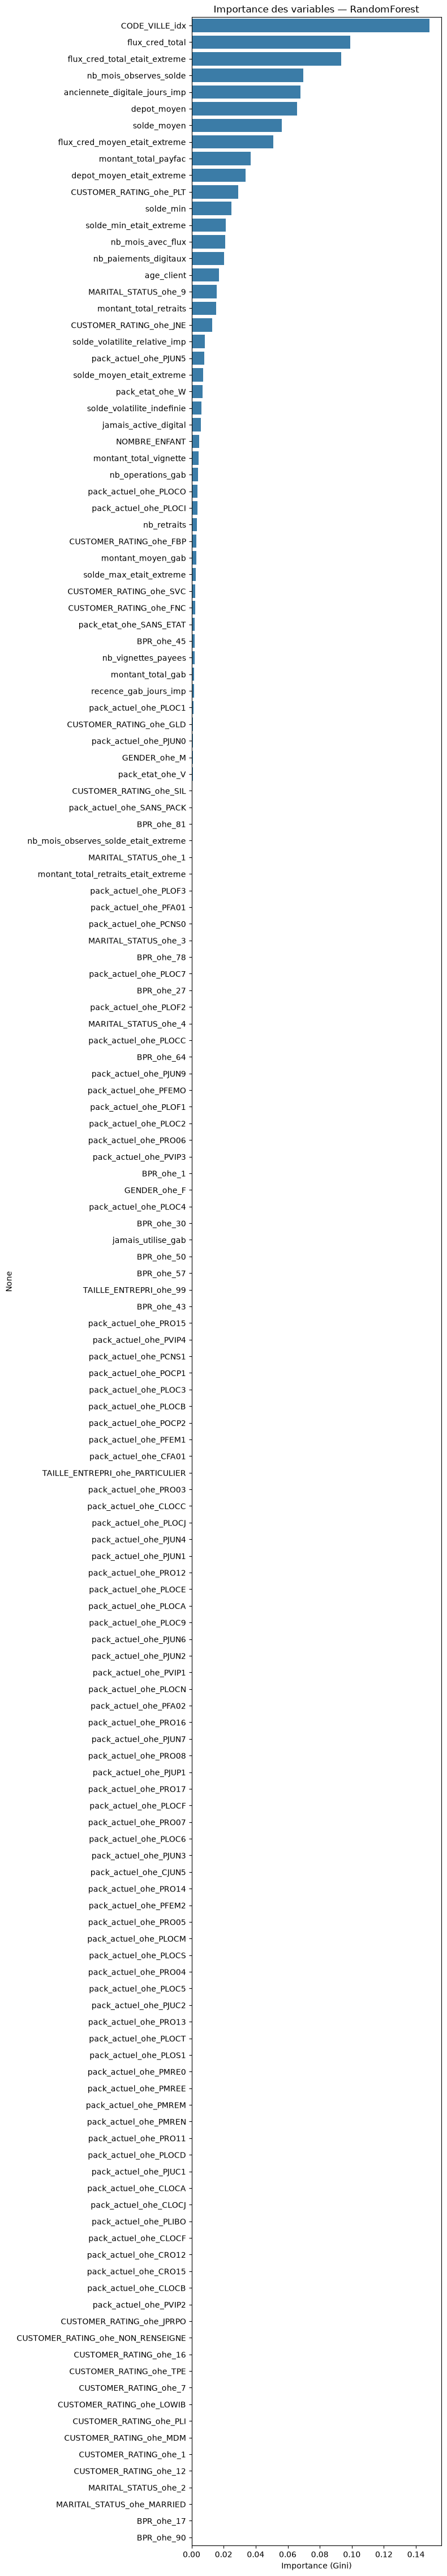

,importance
CODE_VILLE_idx,0.148408
flux_cred_total,0.099169
flux_cred_total_etait_extreme,0.093197
nb_mois_observes_solde,0.069569
anciennete_digitale_jours_imp,0.067893
...,...
CUSTOMER_RATING_ohe_12,0.000000
MARITAL_STATUS_ohe_2,0.000000
MARITAL_STATUS_ohe_MARRIED,0.000000
BPR_ohe_17,0.000000


In [14]:
rf_model = pipeline_model.stages[-1]  # dernier stage du pipeline = le RandomForestClassifier

# CORRECTIF : feature_cols compte une entrée par colonne catégorielle d'origine
# (ex. "GENDER_ohe"), mais OneHotEncoder éclate chacune en plusieurs colonnes
# binaires dans le vecteur "features" assemblé -- la taille ne correspond plus
# (ValueError: Length of values (114) does not match length of index (39)).
# On récupère donc les vrais noms depuis les métadonnées ML posées par le
# VectorAssembler plutôt que de les recompter à la main.
def extraire_noms_features(df, col: str = "features") -> list:
    attrs = df.schema[col].metadata["ml_attr"]["attrs"]
    noms = [None] * sum(len(v) for v in attrs.values())
    for liste_attrs in attrs.values():
        for a in liste_attrs:
            noms[a["idx"]] = a["name"]
    return noms


feature_names_reels = extraire_noms_features(predictions_val)
importances = pd.Series(rf_model.featureImportances.toArray(), index=feature_names_reels)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(importances))))
sns.barplot(x=importances.values, y=importances.index, ax=ax, color="#2980b9")
ax.set_xlabel("Importance (Gini)")
ax.set_title("Importance des variables — RandomForest")
plt.tight_layout()
plt.show()

importances.to_frame("importance")


## 9bis. Benchmark multi-algorithmes avec recherche d'hyperparamètres

Objectif : comparer plusieurs familles d'algorithmes MLlib sur le même split `df_fit` / `df_val`
et les mêmes stages d'encodage (section 6), chacun avec sa propre grille d'hyperparamètres
recherchée par validation croisée (`CrossValidator`, 3 folds), puis les classer sur `df_val`
avec la même métrique que la section 8 (F1 pondéré — la cible est déséquilibrée).

**Algorithmes retenus** — tous supportent nativement le multiclasse (3 classes ici) et `weightCol`,
pour réutiliser la pondération inverse-fréquence de la section 5 :
- `RandomForestClassifier` (déjà utilisé section 7, avec sa grille ici)
- `LogisticRegression` (`family="multinomial"`)
- `DecisionTreeClassifier`
- `NaiveBayes` (`modelType="gaussian"` — le mode `"multinomial"` par défaut exige des features
  non négatives, non garanti ici : `solde_volatilite_relative`, par exemple, peut être négatif)

**Écartés** : `GBTClassifier` et `LinearSVC` ne supportent que le binaire dans MLlib (il faudrait
les envelopper dans un `OneVsRest`, hors périmètre V1.1). `MLPClassifier` ne supporte pas
`weightCol`, ce qui casserait la cohérence avec la pondération de classe de la section 5.

In [15]:
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, NaiveBayes
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

evaluator_f1_cv = MulticlassClassificationEvaluator(
    labelCol="label_idx", predictionCol="prediction", metricName="f1"
)


def construire_pipeline_algo(clf) -> Pipeline:
    """Un pipeline complet par algorithme, réutilisant les MÊMES stages d'encodage
    (section 6) -- StringIndexer/OneHotEncoder n'ont pas encore été fit, donc les
    réutiliser d'un pipeline à l'autre ne partage aucun état appris."""
    return Pipeline(stages=encodage_stages + [label_indexer, assembler, clf])


algos_config = {
    "RandomForest": {
        "clf": RandomForestClassifier(
            labelCol="label_idx", featuresCol="features", predictionCol="prediction",
            probabilityCol="probability", weightCol="poids_classe",
            maxBins=max_bins, seed=RANDOM_SEED,
        ),
        "grid_fn": lambda clf: (
            ParamGridBuilder()
            .addGrid(clf.numTrees, [50, 100, 150])
            .addGrid(clf.maxDepth, [5, 8, 12])
            .build()
        ),
    },
    "LogisticRegression": {
        "clf": LogisticRegression(
            labelCol="label_idx", featuresCol="features", predictionCol="prediction",
            probabilityCol="probability", weightCol="poids_classe", family="multinomial",
        ),
        "grid_fn": lambda clf: (
            ParamGridBuilder()
            .addGrid(clf.regParam, [0.01, 0.1, 0.5])
            .addGrid(clf.elasticNetParam, [0.0, 0.5, 1.0])
            .build()
        ),
    },
    "DecisionTree": {
        "clf": DecisionTreeClassifier(
            labelCol="label_idx", featuresCol="features", predictionCol="prediction",
            probabilityCol="probability", weightCol="poids_classe",
            maxBins=max_bins, seed=RANDOM_SEED,
        ),
        "grid_fn": lambda clf: (
            ParamGridBuilder()
            .addGrid(clf.maxDepth, [5, 8, 12])
            .addGrid(clf.minInstancesPerNode, [1, 5, 10])
            .build()
        ),
    },
    "NaiveBayes_Gaussian": {
        "clf": NaiveBayes(
            labelCol="label_idx", featuresCol="features", predictionCol="prediction",
            probabilityCol="probability", weightCol="poids_classe", modelType="gaussian",
        ),
        # Gaussian NB n'a pas d'hyperparamètre pertinent à balayer ici -- grille vide,
        # CrossValidator sert alors surtout à obtenir un F1 moyen comparable aux autres.
        "grid_fn": lambda clf: ParamGridBuilder().build(),
    },
}

In [16]:
resultats_benchmark = []
modeles_entraines = {}

for nom_algo, config in algos_config.items():
    print(f"\n=== {nom_algo} : recherche d'hyperparamètres (CrossValidator, 3 folds) ===")
    pipeline_algo = construire_pipeline_algo(config["clf"])
    grille = config["grid_fn"](config["clf"])
    print(f"  taille de la grille : {len(grille)} combinaison(s)")

    # CORRECTIF (OOM) : parallelism=2 lance 2 fits simultanément dans la même JVM
    # (mode local) -- avec maxBins ~863 (CODE_VILLE, section 6), chaque fit est déjà
    # coûteux en mémoire ; 2 en parallèle a fait planter le driver (OutOfMemoryError:
    # Java heap space) pendant le benchmark RandomForest. parallelism=1 = plus lent
    # (fits séquentiels) mais stable. À remonter à 2+ seulement si spark.driver.memory
    # (section 2) est généreux par rapport à la RAM de la machine.
    cv = CrossValidator(
        estimator=pipeline_algo,
        estimatorParamMaps=grille,
        evaluator=evaluator_f1_cv,
        numFolds=3,
        seed=RANDOM_SEED,
        parallelism=1,
    )
    cv_model = cv.fit(df_fit)
    meilleur_pipeline = cv_model.bestModel
    modeles_entraines[nom_algo] = meilleur_pipeline

    preds_val = meilleur_pipeline.transform(df_val)
    scores = {
        "algo": nom_algo,
        "f1_cv_moyen": max(cv_model.avgMetrics),
        "f1_val": evaluator_f1.evaluate(preds_val),
        "accuracy_val": evaluator_acc.evaluate(preds_val),
        "precision_val": evaluator_precision.evaluate(preds_val),
        "recall_val": evaluator_recall.evaluate(preds_val),
    }
    resultats_benchmark.append(scores)
    print(f"  F1 (validation) = {scores['f1_val']:.4f}")

df_resultats = pd.DataFrame(resultats_benchmark).sort_values("f1_val", ascending=False).reset_index(drop=True)
df_resultats


=== RandomForest : recherche d'hyperparamètres (CrossValidator, 3 folds) ===
  taille de la grille : 9 combinaison(s)


26/07/15 11:51:09 WARN TaskSetManager: Stage 255 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:51:09 WARN TaskSetManager: Stage 258 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:51:10 WARN TaskSetManager: Stage 259 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:51:11 WARN TaskSetManager: Stage 265 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:51:11 WARN TaskSetManager: Stage 271 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:51:12 WARN TaskSetManager: Stage 277 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 11:51:12 WARN TaskSetManager: Stage 283 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.

  F1 (validation) = 0.8916

=== LogisticRegression : recherche d'hyperparamètres (CrossValidator, 3 folds) ===
  taille de la grille : 9 combinaison(s)


26/07/15 13:45:03 WARN TaskSetManager: Stage 2480 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:45:03 WARN TaskSetManager: Stage 2483 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:45:04 WARN TaskSetManager: Stage 2484 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:45:04 WARN TaskSetManager: Stage 2490 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:45:04 WARN TaskSetManager: Stage 2496 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:45:04 WARN TaskSetManager: Stage 2502 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:45:05 WARN TaskSetManager: Stage 2508 contains a task of very large size (2023 KiB). The maximum recommended task size is 10

  F1 (validation) = 0.8143

=== DecisionTree : recherche d'hyperparamètres (CrossValidator, 3 folds) ===
  taille de la grille : 9 combinaison(s)


26/07/15 13:49:38 WARN TaskSetManager: Stage 6883 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:49:38 WARN TaskSetManager: Stage 6886 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:49:39 WARN TaskSetManager: Stage 6887 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:49:39 WARN TaskSetManager: Stage 6893 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:49:39 WARN TaskSetManager: Stage 6899 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:49:39 WARN TaskSetManager: Stage 6905 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:49:39 WARN TaskSetManager: Stage 6911 contains a task of very large size (2023 KiB). The maximum recommended task size is 10

  F1 (validation) = 0.7847

=== NaiveBayes_Gaussian : recherche d'hyperparamètres (CrossValidator, 3 folds) ===
  taille de la grille : 1 combinaison(s)


26/07/15 13:52:27 WARN TaskSetManager: Stage 9086 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:52:27 WARN TaskSetManager: Stage 9089 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:52:27 WARN TaskSetManager: Stage 9090 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:52:27 WARN TaskSetManager: Stage 9096 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:52:28 WARN TaskSetManager: Stage 9102 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:52:28 WARN TaskSetManager: Stage 9108 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:52:28 WARN TaskSetManager: Stage 9114 contains a task of very large size (2023 KiB). The maximum recommended task size is 10

  F1 (validation) = 0.8004


,algo,f1_cv_moyen,f1_val,accuracy_val,precision_val,recall_val
0,RandomForest,0.899212,0.891600,0.857947,0.934832,0.857947
1,LogisticRegression,0.811630,0.814273,0.734525,0.937633,0.734525
2,NaiveBayes_Gaussian,0.799485,0.800355,0.714108,0.937441,0.714108
3,DecisionTree,0.755805,0.784694,0.691687,0.937258,0.691687


In [21]:
# Hyperparamètres réellement retenus par CrossValidator pour chaque algorithme
# (utile pour figer ces valeurs "en dur" plus tard, ex. section 10, sans repasser par
# CrossValidator à chaque refit -- un refit sur 100% du train avec CV coûterait cher).
params_a_inspecter = (
    "numTrees", "maxDepth", "regParam", "elasticNetParam",
    "minInstancesPerNode", "smoothing",
)

print("Hyperparamètres retenus par algorithme :\n")
for nom_algo, modele in modeles_entraines.items():
    dernier_stage = modele.stages[-1]
    params_interessants = {
        p.name: v for p, v in dernier_stage.extractParamMap().items()
        if p.name in params_a_inspecter
    }
    print(f"{nom_algo:22s} -> {params_interessants}")

Hyperparamètres retenus par algorithme :

RandomForest           -> {'maxDepth': 12, 'minInstancesPerNode': 1, 'numTrees': 150}
LogisticRegression     -> {'elasticNetParam': 0.5, 'regParam': 0.1}
DecisionTree           -> {'maxDepth': 5, 'minInstancesPerNode': 1}
NaiveBayes_Gaussian    -> {'smoothing': 1.0}


## 9ter. Courbes ROC (one-vs-rest) — comparaison des algorithmes

MLlib n'expose pas de courbe ROC multiclasse native (`BinaryClassificationEvaluator` est limité
au binaire). Approche *one-vs-rest* : pour chaque classe `c`, on traite le problème comme
`classe c vs reste`, en utilisant la probabilité prédite pour `c` (colonne `probability`) comme
score et `label_idx == c` comme vérité terrain -- calcul fait avec `sklearn.metrics.roc_curve` sur
`df_val` collecté en pandas (petit volume, même logique que la matrice de confusion section 8).

26/07/15 13:52:51 WARN DAGScheduler: Broadcasting large task binary with size 19.5 MiB
26/07/15 13:52:51 WARN TaskSetManager: Stage 9385 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:52:59 WARN TaskSetManager: Stage 9386 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:00 WARN TaskSetManager: Stage 9387 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:01 WARN TaskSetManager: Stage 9388 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


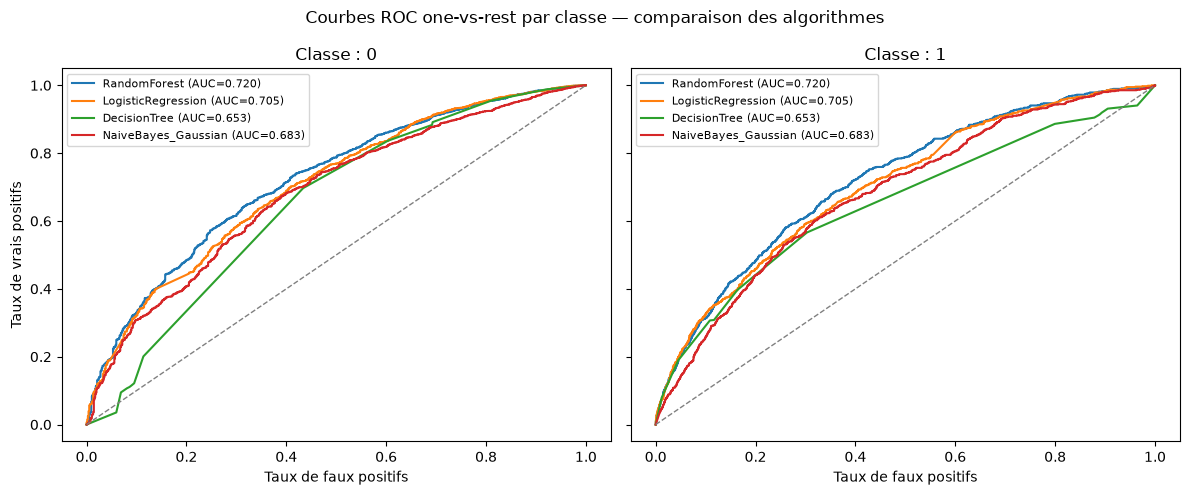

In [18]:
from sklearn.metrics import roc_curve, auc
import numpy as np

label_map_roc = dict(enumerate(modeles_entraines["RandomForest"].stages[len(encodage_stages)].labels))
classes_idx = sorted(label_map_roc.keys())


def extraire_probas_val(modele) -> pd.DataFrame:
    """label_idx réel + une colonne de probabilité prédite par classe, pour df_val."""
    preds = modele.transform(df_val).select("label_idx", "probability").toPandas()
    proba_array = np.vstack(preds["probability"].apply(lambda v: v.toArray()))
    for c in classes_idx:
        preds[f"proba_classe_{c}"] = proba_array[:, c]
    return preds


# Un seul transform() par algorithme (pas par classe) -- réutilisé ensuite pour les
# len(classes_idx) courbes de chaque algo.
probas_par_algo = {nom_algo: extraire_probas_val(modele) for nom_algo, modele in modeles_entraines.items()}

fig, axes = plt.subplots(1, len(classes_idx), figsize=(6 * len(classes_idx), 5), sharey=True)
if len(classes_idx) == 1:
    axes = [axes]

for c, ax in zip(classes_idx, axes):
    for nom_algo, preds_algo in probas_par_algo.items():
        y_true_binaire = (preds_algo["label_idx"] == c).astype(int)
        y_score = preds_algo[f"proba_classe_{c}"]
        fpr, tpr, _ = roc_curve(y_true_binaire, y_score)
        auc_score = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{nom_algo} (AUC={auc_score:.3f})")

    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
    ax.set_title(f"Classe : {label_map_roc[c]}")
    ax.set_xlabel("Taux de faux positifs")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Taux de vrais positifs")
plt.suptitle("Courbes ROC one-vs-rest par classe — comparaison des algorithmes")
plt.tight_layout()
plt.show()

## 10. Refit sur 100% du train (poids recalculés) & sauvegarde

Les métriques de la section 8 valident l'approche sur le split 80/20. Une fois satisfait des
résultats, le modèle **livré** est refit sur `df_train_full` (déjà nettoyé par Tomek Links, section
3) en entier — le split de la section 4 n'existe que pour évaluer honnêtement, il ne doit pas
priver le modèle final de 20% des données. `poids_classe` est **recalculé** ici sur
`df_train_full` : les poids appris sur `df_fit` (80%) ne sont pas exactement ceux de la population
complète.

In [19]:
poids_par_classe_full = calculer_poids_classe(df_train_full)
df_train_full_pondere = df_train_full.join(poids_par_classe_full, on=COL_LABEL)

pipeline_model_final = pipeline.fit(df_train_full_pondere)

pipeline_model_final.write().overwrite().save(MODEL_PATH)
print(f"PipelineModel sauvegardé : {MODEL_PATH}")


26/07/15 13:53:03 WARN TaskSetManager: Stage 9389 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:03 WARN TaskSetManager: Stage 9392 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.



Poids par classe (total=93460, nb_classes=2) :


26/07/15 13:53:03 WARN TaskSetManager: Stage 9398 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


+-----------------+------------------+
|label_eligibilite|      poids_classe|
+-----------------+------------------+
|                0| 0.521813897915201|
|                1|11.960583567954952|
+-----------------+------------------+



26/07/15 13:53:04 WARN TaskSetManager: Stage 9401 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:04 WARN TaskSetManager: Stage 9404 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:04 WARN TaskSetManager: Stage 9410 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:04 WARN TaskSetManager: Stage 9413 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:05 WARN TaskSetManager: Stage 9419 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:05 WARN TaskSetManager: Stage 9422 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:05 WARN TaskSetManager: Stage 9428 contains a task of very large size (2023 KiB). The maximum recommended task size is 10

PipelineModel sauvegardé : ./models/scoring_pipeline


## 11. Scoring (`dataset_a_scorer`)

Chargement du `PipelineModel` sauvegardé et `.transform()` — aucun `.fit()` ici, tout ce qui a été
appris (encodeurs, poids de classe implicites dans l'arbre entraîné, modèle) vient exclusivement
de `df_train_full`.

**CORRECTIF** : la V1 reconstruisait la correspondance indice → nom de produit à la main avec un
`F.udf(...)`. Le guide documente `IndexToString` (section 7.3) pour exactement ce besoin — utilisé
ici à la place.

In [20]:
if PATH_SCORER_IN is not None:
    pipeline_model_reload = PipelineModel.load(MODEL_PATH)
    df_scorer = spark.read.parquet(PATH_SCORER_IN)

    predictions = pipeline_model_reload.transform(df_scorer)

    # Les labels appris par le label_indexer fitté restent accessibles tels quels
    # dans le PipelineModel rechargé -- pas besoin de refitter un indexeur à part
    # juste pour récupérer la liste, contrairement à l'exemple du guide qui refait
    # un indexer.fit(df_final).labels séparé.
    label_indexer_model = pipeline_model_reload.stages[len(encodage_stages)]
    converter = IndexToString(inputCol="prediction", outputCol="label_predit", labels=label_indexer_model.labels)
    predictions = converter.transform(predictions)

    cols_a_garder = [c for c in ["RADICAL", "CODE_VILLE"] if c in predictions.columns] + ["label_predit", "probability"]
    predictions.select(*cols_a_garder).show(20, truncate=False)

    predictions.write.mode("overwrite").parquet(PATH_PREDICTIONS_OUT)
    print(f"Prédictions écrites : {PATH_PREDICTIONS_OUT}")
else:
    print("PATH_SCORER_IN non défini (LOCAL_MODE=True, dataset_a_scorer pas encore testé en local) "
          "-- basculer LOCAL_MODE=False une fois prêt pour le cluster complet.")


PATH_SCORER_IN non défini (LOCAL_MODE=True, dataset_a_scorer pas encore testé en local) -- basculer LOCAL_MODE=False une fois prêt pour le cluster complet.


## 12. Limites de cette V1.1 & prochaines étapes

Cette version corrige les deux lacunes signalées après la V1 (pas de pondération de classe, pas de
Tomek Links) et une affirmation fausse (voir ci-dessous). Points volontairement encore laissés de
côté, à traiter dans une V2 :

- **Correctif V1 → V1.1** : la V1 affirmait que `RandomForestClassifier` "ne supporte pas
  `weightCol` comme `LogisticRegression`". C'était faux et contredisait directement le guide
  (section 7.5, qui utilise `RandomForestClassifier(..., weightCol="poids_classe")`) — Spark 3.0+
  supporte `weightCol` sur `RandomForestClassifier`. Corrigé : la pondération est maintenant
  utilisée (section 5/6).
- **Pas de tuning d'hyperparamètres.** `numTrees=30, maxDepth=5` (section 6) sont des valeurs de
  départ raisonnables, pas optimisées -- alignées ici avec le code (avant correctif, ce texte
  mentionnait `100/8`, incohérent avec les valeurs réellement utilisées). À faire via `CrossValidator` + `ParamGridBuilder` sur `df_fit`
  (jamais sur `df_val`, qui doit rester un set d'évaluation propre — ou passer à un vrai
  train/val/test à 3 blocs si le tuning consomme le set de validation actuel).
- **Tomek Links non paramétré finement.** `sampling_strategy="auto"` nettoie toutes les classes
  majoritaires par défaut — à comparer avec une stratégie ciblée sur la classe la plus
  fréquente uniquement (`sampling_strategy={classe_majoritaire: ...}`) si le F1 des classes
  minoritaires ne s'améliore pas suffisamment.
- **Un seul algorithme essayé.** `RandomForestClassifier` choisi par défaut pour sa robustesse
  aux features non standardisées et à `CODE_VILLE_idx`, et son support natif de `weightCol`. À
  comparer avec `LogisticRegression` (`family="multinomial", weightCol=...`, nécessiterait un
  `StandardScaler` avant le `VectorAssembler`, cf. note EDA sur l'échelle des variables),
  `DecisionTreeClassifier` et `NaiveBayes` (ne supporte pas `weightCol` — guide section 7.9) :
  le guide donne la boucle de comparaison complète (section 7.9).
- **Pas de cross-validation.** Un split 80/20 unique donne une estimation, pas une borne de
  confiance. `CrossValidator` (k=5 par ex.) donnerait une évaluation plus robuste avant la
  décision finale de modèle.
- **`CODE_VILLE_idx` reste un entier arbitraire** pour un modèle à base d'arbres, ce qui est
  acceptable (RandomForest peut apprendre des seuils sur un index sans supposer d'ordre
  linéaire), mais deviendrait un problème si un modèle linéaire est testé en V2 — prévoir un
  encodage par fréquence ou par cible (`target encoding`) à ce moment-là plutôt qu'un `OneHotEncoder`
  brut (273 colonnes).
- **`MODEL_PATH` codé pour un seul modèle**, pas de versionnement — à ajouter (timestamp ou
  numéro de version dans le chemin) avant tout déploiement réel.
- **Tomek Links + refit final (section 10)** : le fichier local de test n'a probablement pas de
  colonne `RADICAL` si `LOCAL_MODE=True` pointe vers un parquet déjà réduit — dans ce cas, la
  branche de repli en section 3 (`RADICAL_PRESENT = False`) reconstruit `df_train_full`
  uniquement à partir des colonnes numériques utilisées par Tomek, ce qui **supprimerait les
  colonnes catégorielles brutes nécessaires à l'encodage (section 6)**. À vérifier explicitement
  avant tout run complet : si `RADICAL` n'est pas dans le parquet nettoyé, l'ajouter en amont
  (Partie 1 EDA) plutôt que de contourner ici.